In [2]:
import pandas as pd

train = pd.read_csv("DailyDelhiClimateTrain.csv")
test = pd.read_csv("DailyDelhiClimateTest.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1462, 5)
Test shape: (114, 5)


In [3]:
train.tail(10)

,date,meantemp,humidity,wind_speed,meanpressure
1452,2016-12-23,15.550000,74.700000,1.205000,1014.250000
1453,2016-12-24,17.318182,78.636364,5.236364,1011.318182
1454,2016-12-25,14.000000,94.300000,9.085000,1014.350000
1455,2016-12-26,17.142857,74.857143,8.784211,1016.952381
1456,2016-12-27,16.850000,67.550000,8.335000,1017.200000
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000
1461,2017-01-01,10.000000,100.000000,0.000000,1016.000000


In [4]:
test.head(10)

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333
5,2017-01-06,19.318182,79.318182,8.681818,1011.772727
6,2017-01-07,14.708333,95.833333,10.041667,1011.375000
7,2017-01-08,15.684211,83.526316,1.950000,1015.550000
8,2017-01-09,14.571429,80.809524,6.542857,1015.952381
9,2017-01-10,12.111111,71.944444,9.361111,1016.888889


In [7]:
train.drop(train.tail(1).index,inplace=True) # drop last raw

In [8]:
train.tail(10)

,date,meantemp,humidity,wind_speed,meanpressure
1450,2016-12-21,18.050000,54.300000,19.404762,1015.619048
1451,2016-12-22,17.285714,57.857143,6.180952,1016.142857
1452,2016-12-23,15.550000,74.700000,1.205000,1014.250000
1453,2016-12-24,17.318182,78.636364,5.236364,1011.318182
1454,2016-12-25,14.000000,94.300000,9.085000,1014.350000
1455,2016-12-26,17.142857,74.857143,8.784211,1016.952381
1456,2016-12-27,16.850000,67.550000,8.335000,1017.200000
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762


split pt validare

- train_data → pentru antrenare
- val_data   → pentru monitorizarea modelului
- test       → evaluare finală

In [9]:
split_index = int(len(train) * 0.75)

train_data = train[:split_index]
val_data = train[split_index:]


Pastram doar coloana de temp => serie de timp UNIVARIATA

In [10]:
train_data = train_data[['date', 'meantemp']]
val_data = val_data[['date', 'meantemp']]
test = test[['date', 'meantemp']]

In [8]:
train_data.head()

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


In [9]:
train_data.tail()

,date,meantemp
1090,2015-12-27,15.375
1091,2015-12-28,17.125
1092,2015-12-29,16.375
1093,2015-12-30,15.500
1094,2015-12-31,15.000


In [10]:
val_data.head()

,date,meantemp
1095,2016-01-01,14.714286
1096,2016-01-02,14.000000
1097,2016-01-03,14.375000
1098,2016-01-04,15.750000
1099,2016-01-05,15.833333


Deci
- train_data → 2013-2015
- val_data   → 2016
- test       → 2017

# Analiza hiperparametru: sequence length

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data[['meantemp']])
val_scaled = scaler.transform(val_data[['meantemp']])
test_scaled = scaler.transform(test[['meantemp']])


In [13]:
# conversie in vectori

train_y = train_scaled.flatten()
val_y = val_scaled.flatten()
test_y = test_scaled.flatten()

In [14]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

# serie: 10 12 13 15 16
# seq_len = 3
# devine
# X = [10,12,13] -> y=15
# X = [12,13,15] -> y=16


In [15]:
def build_lstm_model(seq_len, lr=0.001, units=64):
    model = Sequential()
    model.add(Input(shape=(seq_len, 1)))
    model.add(LSTM(units))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model



In [16]:
def compute_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return mae, rmse

In [17]:
sequence_lengths = range(3, 100)   

results = []

for seq_len in sequence_lengths:

    print(f"Rulez pentru sequence_length = {seq_len}")

    # generăm secvențe
    X_train, y_train = create_sequences(train_y, seq_len)
    X_val, y_val = create_sequences(val_y, seq_len)

    # reshape pentru LSTM
    X_train = X_train.reshape((X_train.shape[0], seq_len, 1))
    X_val = X_val.reshape((X_val.shape[0], seq_len, 1))

    # model
    model = build_lstm_model(seq_len=seq_len, lr=0.001, units=64)

    # antrenare 
    model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        shuffle=False,
        verbose=0
    )

    # predicții
    y_pred = model.predict(X_val, verbose=0).flatten()

    # metrici
    mae, rmse = compute_metrics(y_val, y_pred)

    results.append([seq_len, mae, rmse])

    # afișăm doar rezultatul final
    print(f"   MAE={mae:.4f} | RMSE={rmse:.4f}")

Rulez pentru sequence_length = 3
   MAE=0.0472 | RMSE=0.0618
Rulez pentru sequence_length = 4
   MAE=0.0494 | RMSE=0.0636
Rulez pentru sequence_length = 5
   MAE=0.0503 | RMSE=0.0645
Rulez pentru sequence_length = 6
   MAE=0.0488 | RMSE=0.0625
Rulez pentru sequence_length = 7
   MAE=0.0482 | RMSE=0.0617
Rulez pentru sequence_length = 8
   MAE=0.0489 | RMSE=0.0629
Rulez pentru sequence_length = 9
   MAE=0.0480 | RMSE=0.0617
Rulez pentru sequence_length = 10
   MAE=0.0489 | RMSE=0.0627
Rulez pentru sequence_length = 11
   MAE=0.0497 | RMSE=0.0635
Rulez pentru sequence_length = 12
   MAE=0.0506 | RMSE=0.0648
Rulez pentru sequence_length = 13
   MAE=0.0515 | RMSE=0.0658
Rulez pentru sequence_length = 14
   MAE=0.0485 | RMSE=0.0621
Rulez pentru sequence_length = 15
   MAE=0.0501 | RMSE=0.0640
Rulez pentru sequence_length = 16
   MAE=0.0497 | RMSE=0.0635
Rulez pentru sequence_length = 17
   MAE=0.0509 | RMSE=0.0651
Rulez pentru sequence_length = 18
   MAE=0.0497 | RMSE=0.0638
Rulez pentru se

In [19]:
results_df = pd.DataFrame(
    results,
    columns=['sequence_length','MAE','RMSE']
)


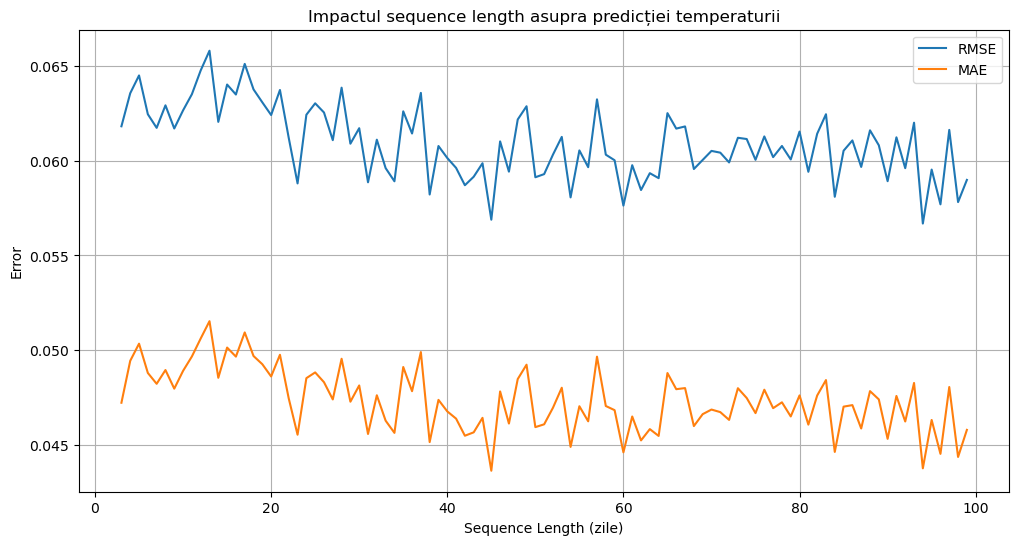

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(results_df['sequence_length'], results_df['RMSE'], label='RMSE')
plt.plot(results_df['sequence_length'], results_df['MAE'], label='MAE')

plt.xlabel("Sequence Length (zile)")
plt.ylabel("Error")
plt.title("Impactul sequence length asupra predicției temperaturii")

plt.legend()
plt.grid(True)
plt.show()


In [21]:
# smoothing

results_df['RMSE_smooth'] = results_df['RMSE'].rolling(window=10).mean()
results_df['MAE_smooth'] = results_df['MAE'].rolling(window=10).mean()

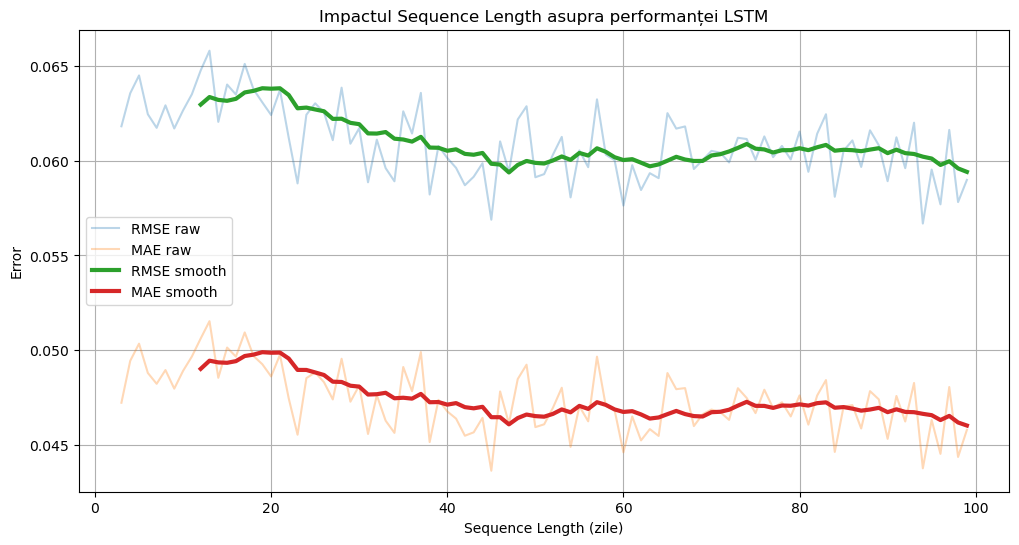

In [22]:
plt.figure(figsize=(12,6))

# curbe originale
plt.plot(results_df['sequence_length'], results_df['RMSE'], alpha=0.3, label='RMSE raw')
plt.plot(results_df['sequence_length'], results_df['MAE'], alpha=0.3, label='MAE raw')

# curbe netezite
plt.plot(results_df['sequence_length'], results_df['RMSE_smooth'], linewidth=3, label='RMSE smooth')
plt.plot(results_df['sequence_length'], results_df['MAE_smooth'], linewidth=3, label='MAE smooth')

plt.xlabel("Sequence Length (zile)")
plt.ylabel("Error")
plt.title("Impactul Sequence Length asupra performanței LSTM")

plt.legend()
plt.grid(True)

plt.show()

In [23]:
best_seq = results_df.loc[results_df['RMSE'].idxmin()]

print("Sequence length optim:")
print(best_seq)

Sequence length optim:
sequence_length    94.000000
MAE                 0.043744
RMSE                0.056687
RMSE_smooth         0.060223
MAE_smooth          0.046625
Name: 91, dtype: float64


In [24]:
best_seq_len = results_df.loc[results_df['RMSE'].idxmin(), 'sequence_length']
print("Sequence length optim:", best_seq_len)

Sequence length optim: 94


In [ ]:
# dar sequence_length 45 are MAE 0.0436 => continuam cu acesta

# Analiza hiperparametrii: forecast lenght

In [25]:
def create_sequences_horizon(data, seq_len, horizon):
    
    X, y = [], []

    for i in range(len(data) - seq_len - horizon + 1):
        
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len + horizon - 1])

    return np.array(X), np.array(y)

In [26]:
forecast_horizons = range(1, 51)   # 1 → 50 zile

In [29]:
seq_len = 45   

forecast_horizons = range(1, 51)

results_forecast = []

for horizon in forecast_horizons:

    print(f"Rulez pentru forecast horizon = {horizon} zile")

    # generare secvențe
    X_train, y_train = create_sequences_horizon(train_y, seq_len, horizon)
    X_val, y_val = create_sequences_horizon(val_y, seq_len, horizon)

    # reshape pentru LSTM
    X_train = X_train.reshape((X_train.shape[0], seq_len, 1))
    X_val = X_val.reshape((X_val.shape[0], seq_len, 1))

    # model
    model = build_lstm_model(seq_len=seq_len)

    model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        shuffle=False,
        verbose=0
    )

    # predict
    y_pred = model.predict(X_val, verbose=0).flatten()

    # metrici
    mae, rmse = compute_metrics(y_val, y_pred)

    results_forecast.append([horizon, mae, rmse])

    print(f"   MAE={mae:.4f} | RMSE={rmse:.4f}")

Rulez pentru forecast horizon = 1 zile
   MAE=0.0465 | RMSE=0.0598
Rulez pentru forecast horizon = 2 zile
   MAE=0.0517 | RMSE=0.0658
Rulez pentru forecast horizon = 3 zile
   MAE=0.0535 | RMSE=0.0672
Rulez pentru forecast horizon = 4 zile
   MAE=0.0557 | RMSE=0.0695
Rulez pentru forecast horizon = 5 zile
   MAE=0.0582 | RMSE=0.0727
Rulez pentru forecast horizon = 6 zile
   MAE=0.0598 | RMSE=0.0744
Rulez pentru forecast horizon = 7 zile
   MAE=0.0603 | RMSE=0.0748
Rulez pentru forecast horizon = 8 zile
   MAE=0.0643 | RMSE=0.0791
Rulez pentru forecast horizon = 9 zile
   MAE=0.0652 | RMSE=0.0799
Rulez pentru forecast horizon = 10 zile
   MAE=0.0672 | RMSE=0.0820
Rulez pentru forecast horizon = 11 zile
   MAE=0.0633 | RMSE=0.0782
Rulez pentru forecast horizon = 12 zile
   MAE=0.0709 | RMSE=0.0863
Rulez pentru forecast horizon = 13 zile
   MAE=0.0684 | RMSE=0.0829
Rulez pentru forecast horizon = 14 zile
   MAE=0.0690 | RMSE=0.0838
Rulez pentru forecast horizon = 15 zile
   MAE=0.0806 | R

In [30]:
results_forecast_df = pd.DataFrame(
    results_forecast,
    columns=['forecast_horizon','MAE','RMSE']
)


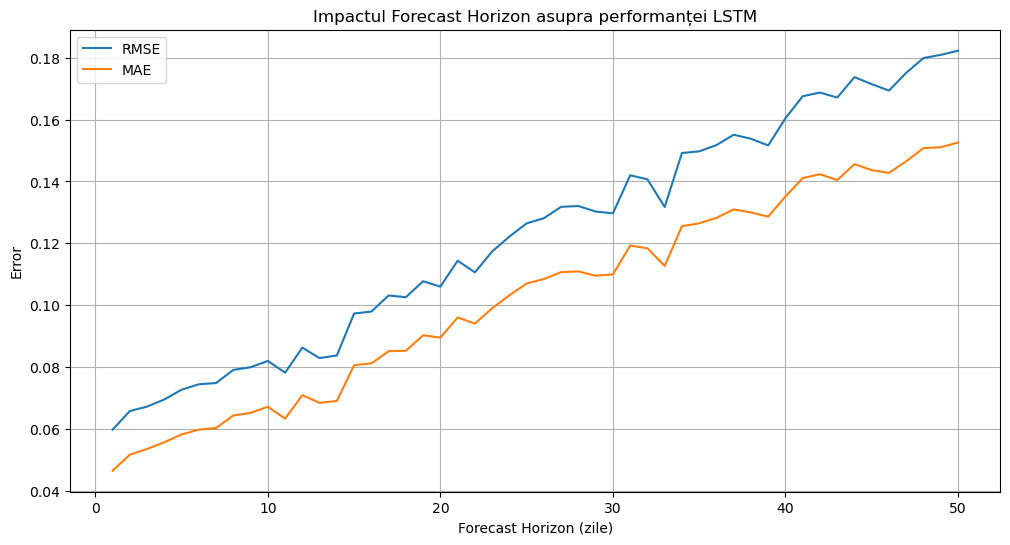

In [31]:
plt.figure(figsize=(12,6))

plt.plot(results_forecast_df['forecast_horizon'], 
         results_forecast_df['RMSE'], label='RMSE')

plt.plot(results_forecast_df['forecast_horizon'], 
         results_forecast_df['MAE'], label='MAE')

plt.xlabel("Forecast Horizon (zile)")
plt.ylabel("Error")
plt.title("Impactul Forecast Horizon asupra performanței LSTM")

plt.legend()
plt.grid(True)

plt.show()

- pastram forecast horizon 1 => predictie MANY TO ONE

# Analiza hiperparametru: learning rate

In [35]:
learning_rates = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.05, 0.1]

results_lr = []

for lr in learning_rates:

    print(f"Rulez pentru learning rate = {lr}")

    # generăm secvențe
    X_train, y_train = create_sequences_horizon(train_y, seq_len, horizon)
    X_val, y_val = create_sequences_horizon(val_y, seq_len, horizon)

    # reshape pentru LSTM
    X_train = X_train.reshape((X_train.shape[0], seq_len, 1))
    X_val = X_val.reshape((X_val.shape[0], seq_len, 1))

    # model
    model = build_lstm_model(seq_len=seq_len, lr=lr)

    model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        shuffle=False,
        verbose=0
    )

    # predicții
    y_pred = model.predict(X_val, verbose=0).flatten()

    # metrici
    mae, rmse = compute_metrics(y_val, y_pred)

    results_lr.append([lr, mae, rmse])

    print(f"   MAE={mae:.4f} | RMSE={rmse:.4f}")

Rulez pentru learning rate = 0.0001
   MAE=0.1702 | RMSE=0.2093
Rulez pentru learning rate = 0.0003
   MAE=0.1572 | RMSE=0.1896
Rulez pentru learning rate = 0.001
   MAE=0.1443 | RMSE=0.1691
Rulez pentru learning rate = 0.003
   MAE=0.1525 | RMSE=0.1813
Rulez pentru learning rate = 0.01
   MAE=0.1528 | RMSE=0.1800
Rulez pentru learning rate = 0.03
   MAE=0.1506 | RMSE=0.1773
Rulez pentru learning rate = 0.05
   MAE=0.1582 | RMSE=0.1818
Rulez pentru learning rate = 0.1
   MAE=0.1569 | RMSE=0.1805


In [36]:
results_lr_df = pd.DataFrame(
    results_lr,
    columns=['learning_rate','MAE','RMSE']
)



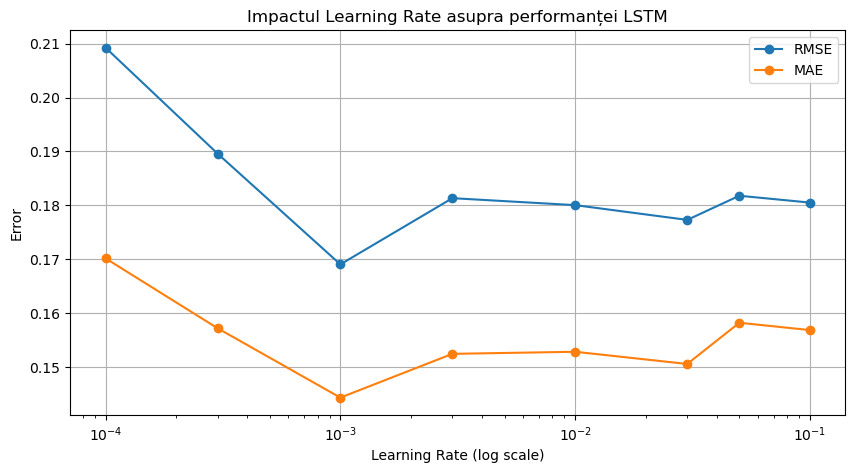

In [37]:
plt.figure(figsize=(10,5))

plt.plot(results_lr_df['learning_rate'],
         results_lr_df['RMSE'],
         marker='o',
         label='RMSE')

plt.plot(results_lr_df['learning_rate'],
         results_lr_df['MAE'],
         marker='o',
         label='MAE')

plt.xscale('log')

plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Error")
plt.title("Impactul Learning Rate asupra performanței LSTM")

plt.legend()
plt.grid(True)

plt.show()

- learning rate optim = 0.001

# Analiza hiperparametrii: units

In [38]:
seq_len = 45
horizon = 1
lr = 0.001
epochs = 20

In [39]:
X_train, y_train = create_sequences_horizon(train_y, seq_len, horizon)
X_val, y_val = create_sequences_horizon(val_y, seq_len, horizon)

X_train = X_train.reshape((X_train.shape[0], seq_len, 1))
X_val = X_val.reshape((X_val.shape[0], seq_len, 1))

In [40]:
units_values = [8, 16, 32, 64, 128]

results_units = []

for units in units_values:

    print(f"Rulez pentru units = {units}")

    model = build_lstm_model(
        seq_len=seq_len,
        lr=lr,
        units=units
    )

    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_val, y_val),
        shuffle=False,
        verbose=0
    )

    y_pred = model.predict(X_val, verbose=0).flatten()

    mae, rmse = compute_metrics(y_val, y_pred)

    results_units.append([units, mae, rmse])

    print(f"   MAE={mae:.4f} | RMSE={rmse:.4f}")

Rulez pentru units = 8
   MAE=0.0442 | RMSE=0.0567
Rulez pentru units = 16
   MAE=0.0475 | RMSE=0.0606
Rulez pentru units = 32
   MAE=0.0457 | RMSE=0.0592
Rulez pentru units = 64
   MAE=0.0435 | RMSE=0.0570
Rulez pentru units = 128
   MAE=0.0449 | RMSE=0.0586


In [41]:
results_units_df = pd.DataFrame(
    results_units,
    columns=['units','MAE','RMSE']
)

results_units_df

,units,MAE,RMSE
0,8,0.044193,0.056735
1,16,0.047518,0.060640
2,32,0.045657,0.059165
3,64,0.043519,0.056989
4,128,0.044879,0.058554


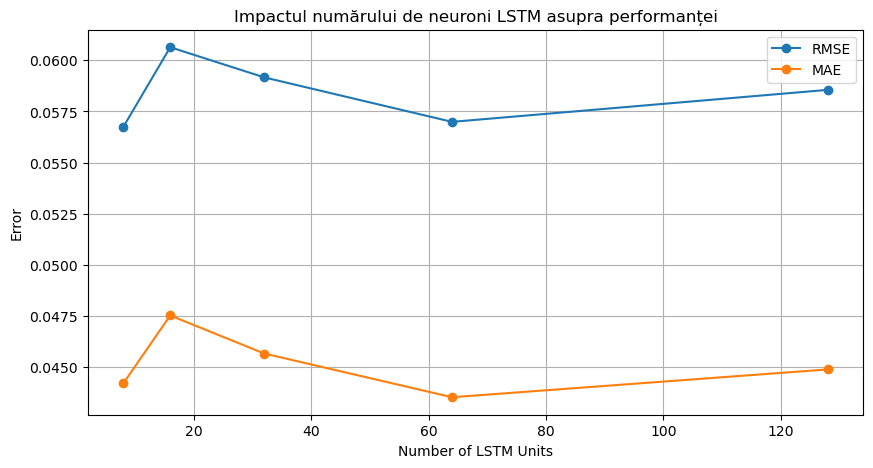

In [42]:
plt.figure(figsize=(10,5))

plt.plot(results_units_df['units'],
         results_units_df['RMSE'],
         marker='o',
         label='RMSE')

plt.plot(results_units_df['units'],
         results_units_df['MAE'],
         marker='o',
         label='MAE')

plt.xlabel("Number of LSTM Units")
plt.ylabel("Error")
plt.title("Impactul numărului de neuroni LSTM asupra performanței")

plt.legend()
plt.grid(True)

plt.show()

# Testare predictie pe anul 2017 (test)

In [44]:
test_input = np.concatenate((val_y, test_y))

In [45]:
X_test = []
y_test = []

for i in range(len(test_input) - seq_len):
    
    X_test.append(test_input[i:i+seq_len])
    y_test.append(test_input[i+seq_len])

X_test = np.array(X_test)
y_test = np.array(y_test)

X_test = X_test.reshape((X_test.shape[0], seq_len, 1))

In [46]:
train_full = np.concatenate((train_y, val_y))

X_train_full, y_train_full = create_sequences(train_full, seq_len)

X_train_full = X_train_full.reshape((X_train_full.shape[0], seq_len, 1))

In [47]:
model_final = build_lstm_model(
    seq_len=seq_len,
    lr=0.001,
    units=64
)

model_final.fit(
    X_train_full,
    y_train_full,
    epochs=20,
    batch_size=32,
    shuffle=False,
    verbose=0
)

In [48]:
y_pred_test = model_final.predict(X_test).flatten()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [49]:
y_pred_test = scaler.inverse_transform(y_pred_test.reshape(-1,1)).flatten()
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [50]:
mae_test, rmse_test = compute_metrics(y_test_real, y_pred_test)

print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test MAE: 1.5666822012808028
Test RMSE: 1.9858151998016196


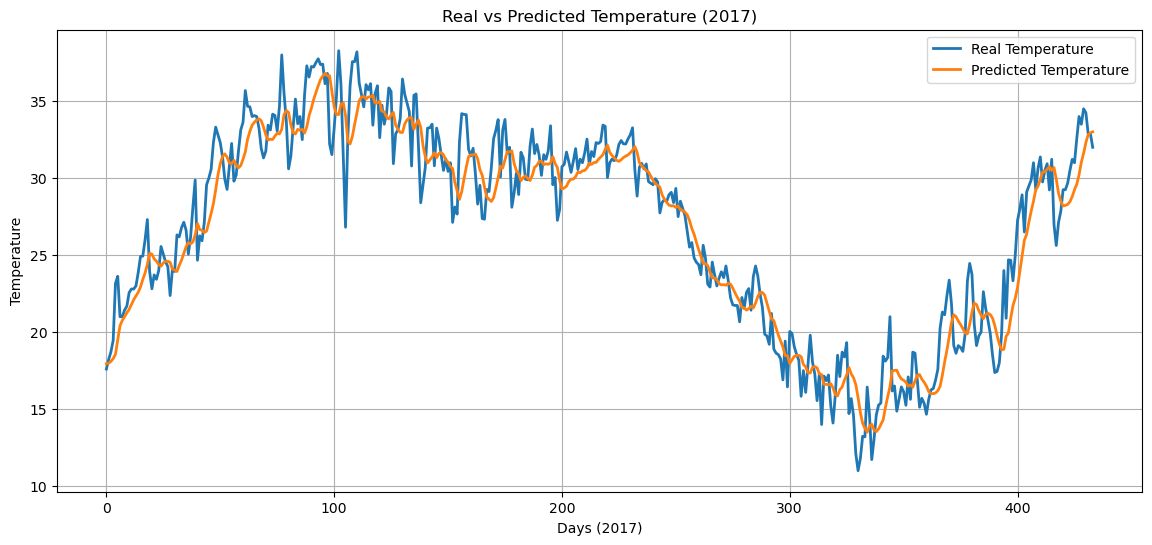

In [51]:
plt.figure(figsize=(14,6))

plt.plot(y_test_real, label="Real Temperature", linewidth=2)
plt.plot(y_pred_test, label="Predicted Temperature", linewidth=2)

plt.xlabel("Days (2017)")
plt.ylabel("Temperature")
plt.title("Real vs Predicted Temperature (2017)")

plt.legend()
plt.grid(True)

plt.show()